In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

plt.rcParams["figure.figsize"]=(12,6)

sns.set_style("whitegrid")

In [18]:
nav_df=pd.read_csv("C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/processed/nav_history_cleaned.csv")

fund_df=pd.read_csv("C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/processed/fund_master_cleaned.csv")

perf_df=pd.read_csv("C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/processed/scheme_performance_cleaned.csv")

"dataset loaded succesfully"

'dataset loaded succesfully'

In [3]:
nav_df.head(50)


,amfi_code,date,nav
0,100016,03-01-2022,520.4608
1,100016,04-01-2022,515.0971
2,100016,05-01-2022,521.7239
3,100016,06-01-2022,515.7880
4,100016,07-01-2022,515.1639
5,100016,10-01-2022,510.7136
6,100016,11-01-2022,513.5542
7,100016,12-01-2022,512.3195
8,100016,13-01-2022,510.2445
9,100016,14-01-2022,514.3636


In [4]:
nav_df.shape


(46000, 3)

In [5]:
nav_df.dtypes

amfi_code      int64
date          object
nav          float64
dtype: object

In [6]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    format="%d-%m-%Y"
)

print(nav_df["date"].dtype)

datetime64[ns]


In [7]:
nav_df["daily_return"] = (
nav_df.groupby("amfi_code")["nav"].pct_change()
)

#this calculates daily returns 

In [8]:

nav_df = nav_df.dropna(
    subset=["daily_return"]
)

In [14]:
def calculate_cagr(start_nav, end_nav, years):

    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1

    return cagr


In [15]:
cagr_results = []

In [19]:
cagr_df = pd.DataFrame(cagr_results)

print(cagr_df.head())

Empty DataFrame
Columns: []
Index: []


In [24]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print(nav_df["date"].dtype)

nav_df = nav_df.sort_values(
    by=["amfi_code", "date"]
)
def calculate_cagr(start_nav, end_nav, years):

    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1

    return cagr

cagr_df = pd.DataFrame(cagr_results)

print(cagr_df.head())

print(cagr_df.columns)



cagr_df["cagr_pct"] = (
    cagr_df["cagr"] * 100
)




datetime64[ns]
   amfi_code  start_nav   end_nav  years      cagr
0     100016   520.4608  583.6113    4.4  0.026352
1     100025    26.3169   31.8843    4.4  0.044551
2     100033   107.3758  342.0072    4.4  0.300997
3     101206   305.0996  773.2939    4.4  0.235205
4     101207    38.5736   53.9836    4.4  0.079331
Index(['amfi_code', 'start_nav', 'end_nav', 'years', 'cagr'], dtype='object')


In [25]:
for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ].sort_values("date")


    if len(fund_data) < 2:
        continue

    start_nav = fund_data.iloc[0]["nav"]

    end_nav = fund_data.iloc[-1]["nav"]

    total_years = (
        (
            fund_data.iloc[-1]["date"] - fund_data.iloc[0]["date"]
        ).days
    ) / 365

    if total_years <= 0:
        continue

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        total_years
    )

    cagr_results.append({
        "amfi_code": fund,
        "start_nav": start_nav,
        "end_nav": end_nav,
        "years": round(total_years, 2),
        "cagr": cagr
    })

In [26]:
cagr_df["cagr_pct"] = (
    cagr_df["cagr"] * 100
)

print(
    cagr_df[
        [
            "amfi_code",
            "cagr_pct"
        ]
    ].head()
)



   amfi_code   cagr_pct
0     100016   2.635246
1     100025   4.455091
2     100033  30.099704
3     101206  23.520489
4     101207   7.933121


In [27]:
cagr_df = cagr_df.merge(
    fund_df[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(
    cagr_df[
        [
            "scheme_name",
            "cagr_pct"
        ]
    ].head()
)





                                         scheme_name   cagr_pct
0          HDFC Top 100 Fund - Regular Plan - Growth   2.635246
1       HDFC Short Term Debt Fund - Regular - Growth   4.455091
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  30.099704
3      ABSL Frontline Equity Fund - Regular - Growth  23.520489
4             ABSL Small Cap Fund - Regular - Growth   7.933121


In [28]:

# TOP CAGR FUNDS

top_cagr = cagr_df.sort_values(
    by="cagr_pct",
    ascending=False
).head(10)

print(
    top_cagr[
        [
            "scheme_name",
            "cagr_pct"
        ]
    ]
)



                                      scheme_name   cagr_pct
65       ICICI Pru Midcap Fund - Regular - Growth  32.801599
25       ICICI Pru Midcap Fund - Regular - Growth  32.801599
21     SBI Small Cap Fund - Regular Plan - Growth  32.398084
61     SBI Small Cap Fund - Regular Plan - Growth  32.398084
79          DSP Small Cap Fund - Regular - Growth  32.262108
39          DSP Small Cap Fund - Regular - Growth  32.262108
76  Mirae Asset Tax Saver Fund - Regular - Growth  31.924486
36  Mirae Asset Tax Saver Fund - Regular - Growth  31.924486
74  Mirae Asset Large Cap Fund - Regular - Growth  30.949920
34  Mirae Asset Large Cap Fund - Regular - Growth  30.949920


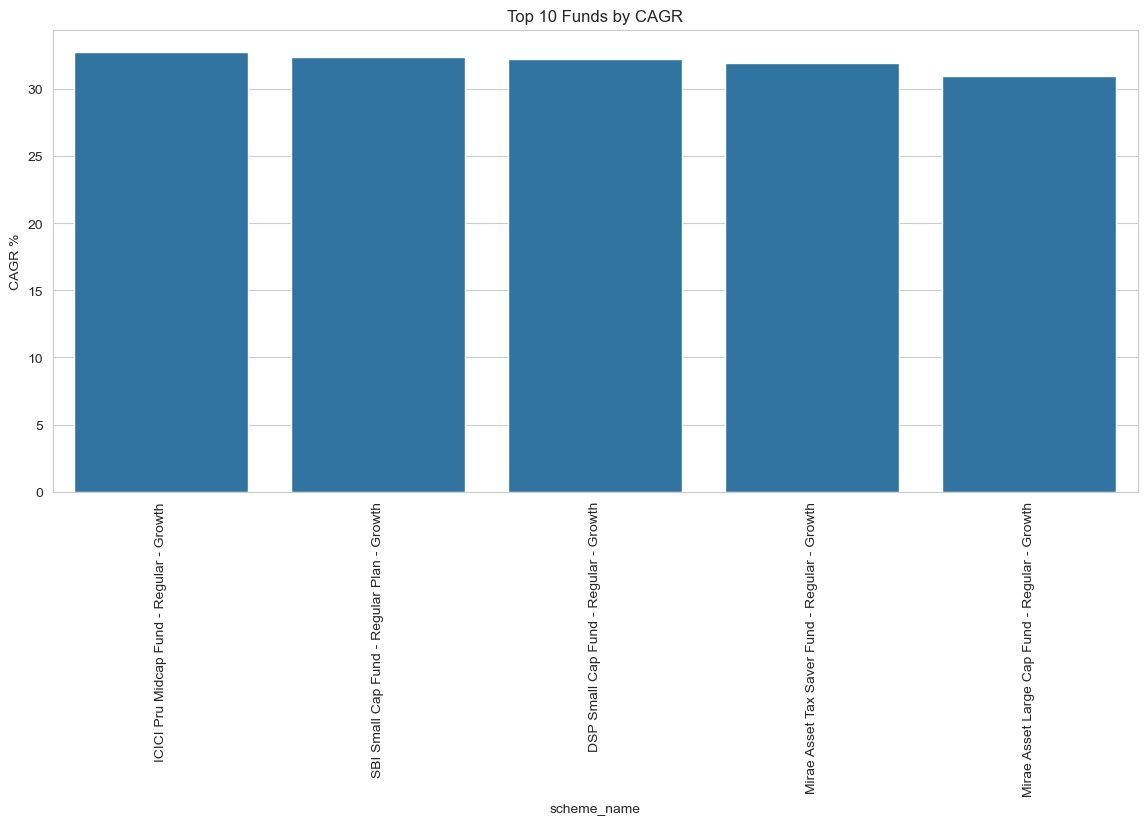

In [29]:

# CAGR VISUALIZATION


plt.figure(figsize=(14,6))

sns.barplot(
    data=top_cagr,
    x="scheme_name",
    y="cagr_pct"
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by CAGR")

plt.ylabel("CAGR %")

plt.show()


In [34]:
risk_free_rate = 0.065

In [35]:
sharpe_results = []

In [40]:

nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    format="%d-%m-%Y",
    errors="coerce"
)

nav_df = nav_df.sort_values(
    by=["amfi_code", "date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_df = nav_df.dropna(
    subset=["daily_return"]
)

print(nav_df.columns)

print(nav_df.head())




Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')
   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639


In [41]:
for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"]

    # Skip empty returns
    if len(fund_returns) == 0:
        continue

    avg_daily_return = fund_returns.mean()

    daily_std = fund_returns.std()

    # Skip zero volatility
    if daily_std == 0:
        continue

    # Annualized return
    annual_return = avg_daily_return * 252

    # Annualized volatility
    annual_std = daily_std * np.sqrt(252)

    sharpe_ratio = (
        (annual_return - risk_free_rate)
        /
        annual_std
    )

    sharpe_results.append({
        "amfi_code": fund,
        "annual_return": annual_return,
        "annual_volatility": annual_std,
        "sharpe_ratio": sharpe_ratio
    })



In [43]:
sharpe_df = pd.DataFrame(
    sharpe_results
)

print(sharpe_df.head())


   amfi_code  annual_return  annual_volatility  sharpe_ratio
0     100016       0.035683           0.145481     -0.201517
1     100025       0.042854           0.039052     -0.567095
2     100033       0.272111           0.189367      1.093699
3     101206       0.214647           0.145682      1.027213
4     101207       0.106962           0.257973      0.162661


In [44]:


sharpe_df = sharpe_df.merge(
    fund_df[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(
    sharpe_df[
        [
            "scheme_name",
            "sharpe_ratio"
        ]
    ].head()
)



                                         scheme_name  sharpe_ratio
0          HDFC Top 100 Fund - Regular Plan - Growth     -0.201517
1       HDFC Short Term Debt Fund - Regular - Growth     -0.567095
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...      1.093699
3      ABSL Frontline Equity Fund - Regular - Growth      1.027213
4             ABSL Small Cap Fund - Regular - Growth      0.162661


In [45]:
top_sharpe = sharpe_df.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(10)

print(
    top_sharpe[
        [
            "scheme_name",
            "sharpe_ratio"
        ]
    ]
)



                                          scheme_name  sharpe_ratio
34      Mirae Asset Large Cap Fund - Regular - Growth      1.448291
30             Kotak Flexicap Fund - Regular - Growth      1.306744
36      Mirae Asset Tax Saver Fund - Regular - Growth      1.234930
19          SBI Bluechip Fund - Regular Plan - Growth      1.208267
25           ICICI Pru Midcap Fund - Regular - Growth      1.180101
38                 DSP Midcap Fund - Regular - Growth      1.132122
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...      1.093699
9      Nippon India Large Cap Fund - Regular - Growth      1.081659
3       ABSL Frontline Equity Fund - Regular - Growth      1.027213
24          ICICI Pru Bluechip Fund - Direct - Growth      1.026524


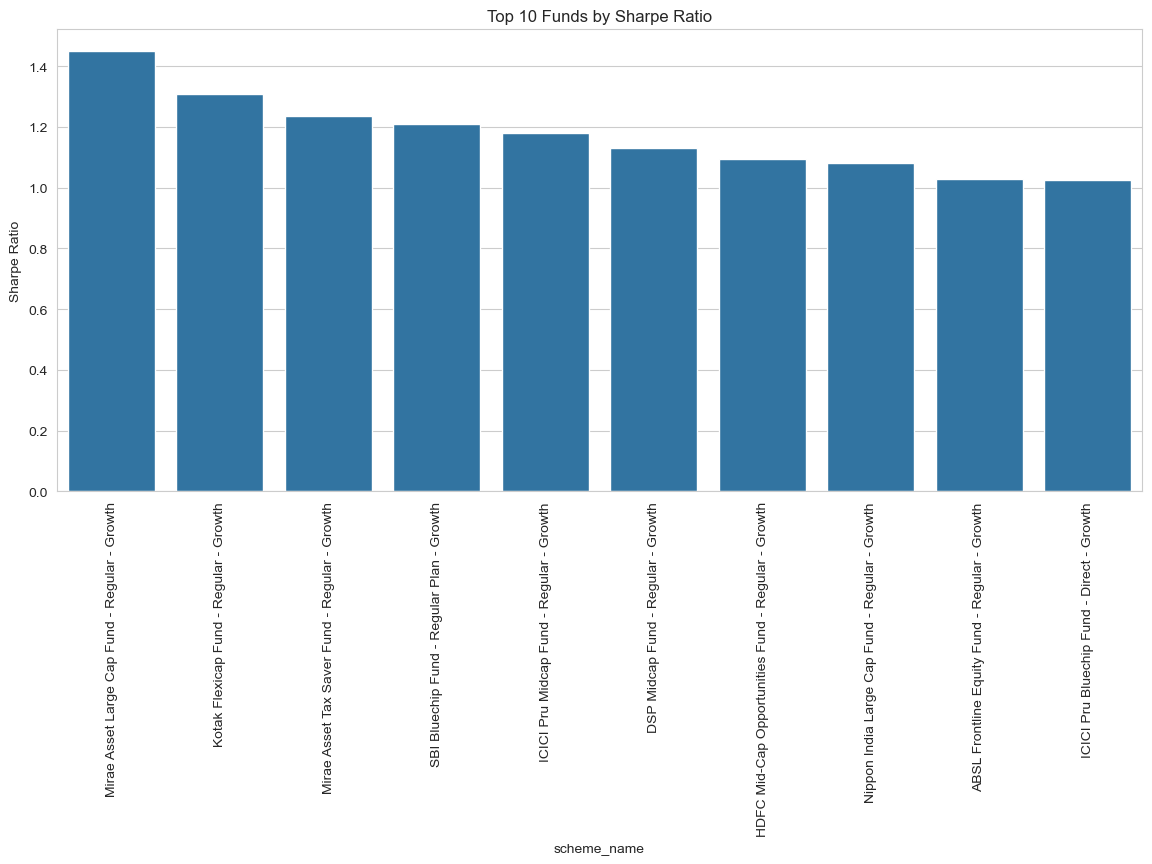

In [46]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=top_sharpe,
    x="scheme_name",
    y="sharpe_ratio"
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.ylabel("Sharpe Ratio")

plt.show()



In [47]:
sortino_results=[]

In [48]:

for fund in nav_df["amfi_code"].unique():

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"]

    if len(fund_returns) == 0:
        continue

    avg_daily_return = fund_returns.mean()

    # ONLY NEGATIVE RETURNS
    downside_returns = fund_returns[
        fund_returns < 0
    ]

    # Skip if no downside returns
    if len(downside_returns) == 0:
        continue

    downside_std = downside_returns.std()

    # Avoid division by zero
    if downside_std == 0:
        continue

    annual_return = avg_daily_return * 252

    annual_downside_std = (
        downside_std * np.sqrt(252)
    )

    sortino_ratio = (
        (annual_return - risk_free_rate)
        /
        annual_downside_std
    )

    sortino_results.append({
        "amfi_code": fund,
        "annual_return": annual_return,
        "downside_risk": annual_downside_std,
        "sortino_ratio": sortino_ratio
    })

In [49]:
sortino_df = pd.DataFrame(
    sortino_results
)

print(sortino_df.head())


   amfi_code  annual_return  downside_risk  sortino_ratio
0     100016       0.035683       0.083513      -0.351047
1     100025       0.042854       0.023514      -0.941821
2     100033       0.272111       0.113229       1.829134
3     101206       0.214647       0.083157       1.799563
4     101207       0.106962       0.151683       0.276644


In [50]:
sortino_df = sortino_df.merge(
    fund_df[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(
    sortino_df[
        [
            "scheme_name",
            "sortino_ratio"
        ]
    ].head()
)


                                         scheme_name  sortino_ratio
0          HDFC Top 100 Fund - Regular Plan - Growth      -0.351047
1       HDFC Short Term Debt Fund - Regular - Growth      -0.941821
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...       1.829134
3      ABSL Frontline Equity Fund - Regular - Growth       1.799563
4             ABSL Small Cap Fund - Regular - Growth       0.276644


In [51]:
top_sortino = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
).head(10)

print(
    top_sortino[
        [
            "scheme_name",
            "sortino_ratio"
        ]
    ]
)

                                          scheme_name  sortino_ratio
34      Mirae Asset Large Cap Fund - Regular - Growth       2.385644
30             Kotak Flexicap Fund - Regular - Growth       2.364320
36      Mirae Asset Tax Saver Fund - Regular - Growth       2.146914
19          SBI Bluechip Fund - Regular Plan - Growth       2.140267
25           ICICI Pru Midcap Fund - Regular - Growth       2.029353
38                 DSP Midcap Fund - Regular - Growth       1.875101
9      Nippon India Large Cap Fund - Regular - Growth       1.850133
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...       1.829134
24          ICICI Pru Bluechip Fund - Direct - Growth       1.805294
3       ABSL Frontline Equity Fund - Regular - Growth       1.799563


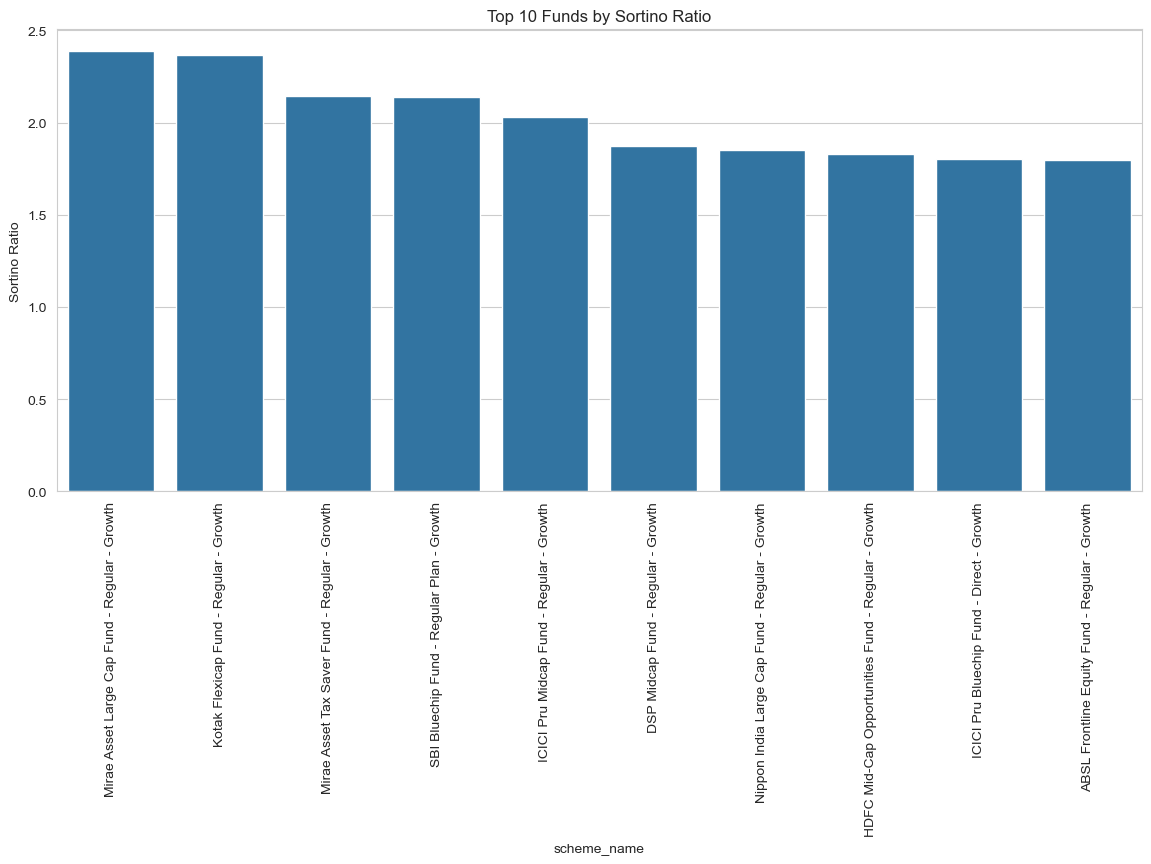

In [52]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=top_sortino,
    x="scheme_name",
    y="sortino_ratio"
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sortino Ratio")

plt.ylabel("Sortino Ratio")

plt.show()

In [53]:

benchmark_df = nav_df.groupby(
    "date"
)["daily_return"].mean().reset_index()

benchmark_df = benchmark_df.rename(
    columns={
        "daily_return": "market_return"
    }
)

print(benchmark_df.head())


        date  market_return
0 2022-01-04      -0.001451
1 2022-01-05       0.001977
2 2022-01-06       0.000341
3 2022-01-07       0.000627
4 2022-01-10       0.001724


In [54]:
alpha_beta_results = []

In [56]:

for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ][
        [
            "date",
            "daily_return"
        ]
    ]

    merged_df = fund_data.merge(
        benchmark_df,
        on="date",
        how="inner"
    )

    # Skip insufficient data
    if len(merged_df) < 2:
        continue

    regression = linregress(
        merged_df["market_return"],
        merged_df["daily_return"]
    )

    beta = regression.slope

    alpha = (
        regression.intercept * 252
    )

    alpha_beta_results.append({
        "amfi_code": fund,
        "alpha": alpha,
        "beta": beta
    })


In [57]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

print(alpha_beta_df.head())

   amfi_code     alpha      beta
0     100016 -0.089699  0.788441
1     100025  0.033199  0.060713
2     100033  0.114423  0.991590
3     101206  0.097443  0.737015
4     101207 -0.350741  2.878184


In [58]:
alpha_beta_df = alpha_beta_df.merge(
    fund_df[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(
    alpha_beta_df[
        [
            "scheme_name",
            "alpha",
            "beta"
        ]
    ].head()
)

                                         scheme_name     alpha      beta
0          HDFC Top 100 Fund - Regular Plan - Growth -0.089699  0.788441
1       HDFC Short Term Debt Fund - Regular - Growth  0.033199  0.060713
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.114423  0.991590
3      ABSL Frontline Equity Fund - Regular - Growth  0.097443  0.737015
4             ABSL Small Cap Fund - Regular - Growth -0.350741  2.878184


In [59]:
top_alpha = alpha_beta_df.sort_values(
    by="alpha",
    ascending=False
).head(10)

print(
    top_alpha[
        [
            "scheme_name",
            "alpha",
            "beta"
        ]
    ]
)

                                          scheme_name     alpha      beta
34      Mirae Asset Large Cap Fund - Regular - Growth  0.181968  0.557134
74      Mirae Asset Large Cap Fund - Regular - Growth  0.181968  0.557134
59          SBI Bluechip Fund - Regular Plan - Growth  0.141513  0.562931
19          SBI Bluechip Fund - Regular Plan - Growth  0.141513  0.562931
64          ICICI Pru Bluechip Fund - Direct - Growth  0.115994  0.606529
24          ICICI Pru Bluechip Fund - Direct - Growth  0.115994  0.606529
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.114423  0.991590
42  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.114423  0.991590
25           ICICI Pru Midcap Fund - Regular - Growth  0.102647  1.194815
65           ICICI Pru Midcap Fund - Regular - Growth  0.102647  1.194815


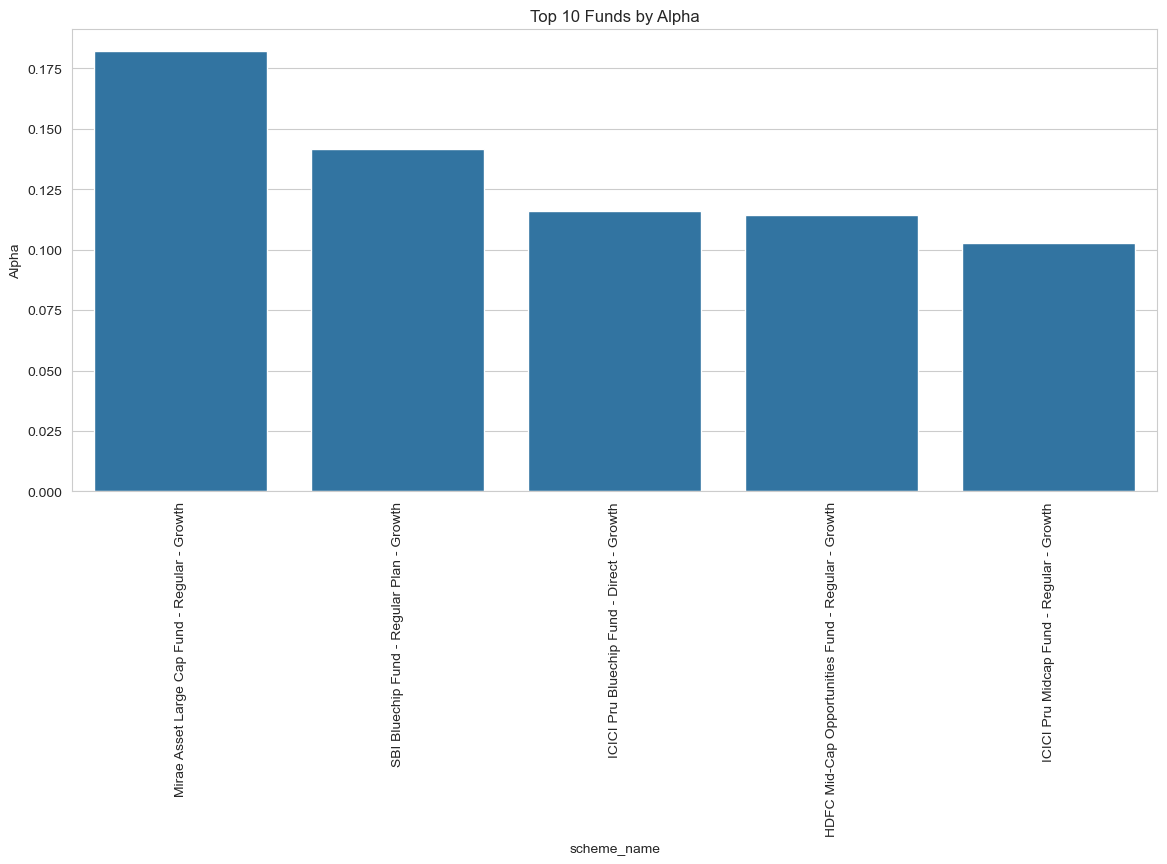

In [60]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=top_alpha,
    x="scheme_name",
    y="alpha"
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Alpha")

plt.ylabel("Alpha")

plt.show()

In [61]:
drawdown_results = []

In [62]:
for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[
        nav_df["amfi_code"] == fund
    ].sort_values("date")

    # Running maximum NAV
    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    # Drawdown calculation
    fund_data["drawdown"] = (
        (
            fund_data["nav"]
            /
            fund_data["running_max"]
        ) - 1
    )

    # Maximum drawdown
    max_drawdown = fund_data[
        "drawdown"
    ].min()

    # Worst drawdown row
    worst_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    drawdown_results.append({
        "amfi_code": fund,
        "max_drawdown": max_drawdown,
        "worst_date": worst_row["date"]
    })

In [63]:
drawdown_df = pd.DataFrame(
    drawdown_results
)

print(drawdown_df.head())

   amfi_code  max_drawdown worst_date
0     100016     -0.247344 2022-09-15
1     100025     -0.043083 2023-07-28
2     100033     -0.162172 2022-05-12
3     101206     -0.112916 2023-07-05
4     101207     -0.354469 2026-05-11


In [64]:
drawdown_df = drawdown_df.merge(
    fund_df[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(
    drawdown_df[
        [
            "scheme_name",
            "max_drawdown"
        ]
    ].head()
)

                                         scheme_name  max_drawdown
0          HDFC Top 100 Fund - Regular Plan - Growth     -0.247344
1       HDFC Short Term Debt Fund - Regular - Growth     -0.043083
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...     -0.162172
3      ABSL Frontline Equity Fund - Regular - Growth     -0.112916
4             ABSL Small Cap Fund - Regular - Growth     -0.354469


In [65]:
worst_drawdowns = drawdown_df.sort_values(
    by="max_drawdown"
).head(10)

print(
    worst_drawdowns[
        [
            "scheme_name",
            "max_drawdown",
            "worst_date"
        ]
    ]
)

                                       scheme_name  max_drawdown worst_date
22       SBI Small Cap Fund - Direct Plan - Growth     -0.525742 2025-10-28
17          Axis Small Cap Fund - Regular - Growth     -0.516778 2026-05-11
4           ABSL Small Cap Fund - Regular - Growth     -0.354469 2026-05-11
39           DSP Small Cap Fund - Regular - Growth     -0.311719 2025-01-03
21      SBI Small Cap Fund - Regular Plan - Growth     -0.287060 2025-05-14
7              UTI Mid Cap Fund - Regular - Growth     -0.280011 2026-04-27
0        HDFC Top 100 Fund - Regular Plan - Growth     -0.247344 2022-09-15
29   Kotak Emerging Equity Fund - Regular - Growth     -0.240035 2024-10-17
11  Nippon India Small Cap Fund - Regular - Growth     -0.233449 2026-02-20
15            Axis Bluechip Fund - Direct - Growth     -0.217514 2023-05-22


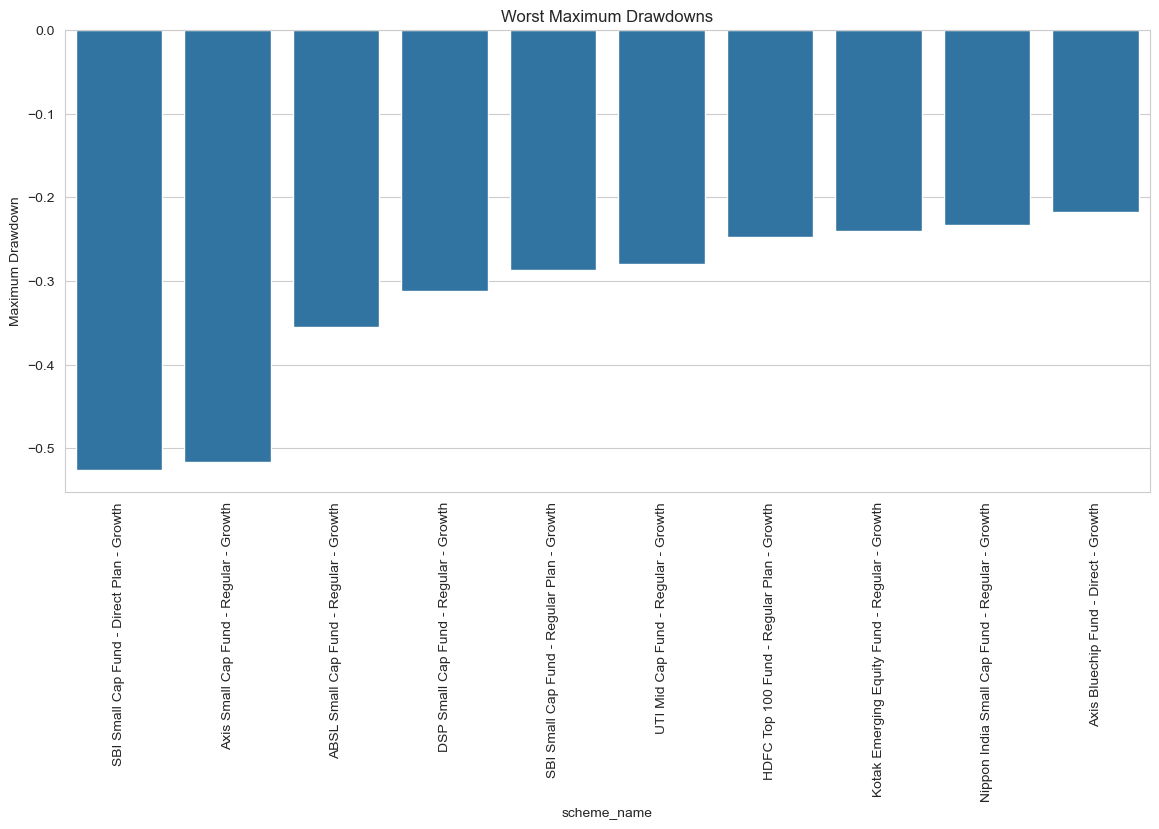

In [66]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=worst_drawdowns,
    x="scheme_name",
    y="max_drawdown"
)

plt.xticks(rotation=90)

plt.title("Worst Maximum Drawdowns")

plt.ylabel("Maximum Drawdown")

plt.show()

In [67]:
scorecard_df = fund_df[
    [
        "amfi_code",
        "scheme_name",
        "expense_ratio_pct"
    ]
].copy()

print(scorecard_df.head())


   amfi_code                                   scheme_name  expense_ratio_pct
0     119551     SBI Bluechip Fund - Regular Plan - Growth               1.54
1     119552      SBI Bluechip Fund - Direct Plan - Growth               0.66
2     119598    SBI Small Cap Fund - Regular Plan - Growth               1.43
3     119599     SBI Small Cap Fund - Direct Plan - Growth               0.72
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth               0.77


In [68]:


scorecard_df = scorecard_df.merge(
    cagr_df[
        [
            "amfi_code",
            "cagr_pct"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(scorecard_df.head())


   amfi_code                                 scheme_name  expense_ratio_pct  \
0     119551   SBI Bluechip Fund - Regular Plan - Growth               1.54   
1     119551   SBI Bluechip Fund - Regular Plan - Growth               1.54   
2     119552    SBI Bluechip Fund - Direct Plan - Growth               0.66   
3     119552    SBI Bluechip Fund - Direct Plan - Growth               0.66   
4     119598  SBI Small Cap Fund - Regular Plan - Growth               1.43   

    cagr_pct  
0  25.784921  
1  25.784921  
2  21.508022  
3  21.508022  
4  32.398084  


In [79]:

scorecard_df = scorecard_df.merge(
    alpha_beta_df[
        [
            "amfi_code",
            "alpha"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(scorecard_df.columns)


Index(['amfi_code', 'scheme_name', 'expense_ratio_pct', 'cagr_pct',
       'sharpe_ratio', 'max_drawdown_x', 'cagr_rank', 'sharpe_rank',
       'max_drawdown_y', 'max_drawdown', 'alpha'],
      dtype='object')


In [69]:

scorecard_df = scorecard_df.merge(
    sharpe_df[
        [
            "amfi_code",
            "sharpe_ratio"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(scorecard_df.head())


   amfi_code                                 scheme_name  expense_ratio_pct  \
0     119551   SBI Bluechip Fund - Regular Plan - Growth               1.54   
1     119551   SBI Bluechip Fund - Regular Plan - Growth               1.54   
2     119552    SBI Bluechip Fund - Direct Plan - Growth               0.66   
3     119552    SBI Bluechip Fund - Direct Plan - Growth               0.66   
4     119598  SBI Small Cap Fund - Regular Plan - Growth               1.43   

    cagr_pct  sharpe_ratio  
0  25.784921      1.208267  
1  25.784921      1.208267  
2  21.508022      0.953279  
3  21.508022      0.953279  
4  32.398084      0.945308  


In [77]:

scorecard_df = scorecard_df.merge(
    drawdown_df[
        [
            "amfi_code",
            "max_drawdown"
        ]
    ],
    on="amfi_code",
    how="left"
)

print(scorecard_df.head())


   amfi_code                                 scheme_name  expense_ratio_pct  \
0     119551   SBI Bluechip Fund - Regular Plan - Growth               1.54   
1     119551   SBI Bluechip Fund - Regular Plan - Growth               1.54   
2     119552    SBI Bluechip Fund - Direct Plan - Growth               0.66   
3     119552    SBI Bluechip Fund - Direct Plan - Growth               0.66   
4     119598  SBI Small Cap Fund - Regular Plan - Growth               1.43   

    cagr_pct  sharpe_ratio  max_drawdown_x  cagr_rank  sharpe_rank  \
0  25.784921      1.208267       -0.150124       19.5          7.5   
1  25.784921      1.208267       -0.150124       19.5          7.5   
2  21.508022      0.953279       -0.118035       29.5         23.5   
3  21.508022      0.953279       -0.118035       29.5         23.5   
4  32.398084      0.945308       -0.287060        3.5         27.5   

   max_drawdown_y  max_drawdown  
0       -0.150124     -0.150124  
1       -0.150124     -0.150124  
2 

In [78]:

print(alpha_beta_df.columns)

print(alpha_beta_df.head())



Index(['amfi_code', 'alpha', 'beta', 'scheme_name'], dtype='object')
   amfi_code     alpha      beta  \
0     100016 -0.089699  0.788441   
1     100025  0.033199  0.060713   
2     100033  0.114423  0.991590   
3     101206  0.097443  0.737015   
4     101207 -0.350741  2.878184   

                                         scheme_name  
0          HDFC Top 100 Fund - Regular Plan - Growth  
1       HDFC Short Term Debt Fund - Regular - Growth  
2  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
3      ABSL Frontline Equity Fund - Regular - Growth  
4             ABSL Small Cap Fund - Regular - Growth  


In [80]:

# Higher CAGR is better
scorecard_df["cagr_rank"] = (
    scorecard_df["cagr_pct"]
    .rank(ascending=False)
)

# Higher Sharpe is better
scorecard_df["sharpe_rank"] = (
    scorecard_df["sharpe_ratio"]
    .rank(ascending=False)
)

# Higher Alpha is better
scorecard_df["alpha_rank"] = (
    scorecard_df["alpha"]
    .rank(ascending=False)
)

# Lower Expense Ratio is better
scorecard_df["expense_rank"] = (
    scorecard_df["expense_ratio_pct"]
    .rank(ascending=True)
)

# Lower Drawdown is better
scorecard_df["drawdown_rank"] = (
    scorecard_df["max_drawdown"]
    .rank(ascending=True)
)

print(scorecard_df.head())


   amfi_code                                scheme_name  expense_ratio_pct  \
0     119551  SBI Bluechip Fund - Regular Plan - Growth               1.54   
1     119551  SBI Bluechip Fund - Regular Plan - Growth               1.54   
2     119551  SBI Bluechip Fund - Regular Plan - Growth               1.54   
3     119551  SBI Bluechip Fund - Regular Plan - Growth               1.54   
4     119552   SBI Bluechip Fund - Direct Plan - Growth               0.66   

    cagr_pct  sharpe_ratio  max_drawdown_x  cagr_rank  sharpe_rank  \
0  25.784921      1.208267       -0.150124       38.5         14.5   
1  25.784921      1.208267       -0.150124       38.5         14.5   
2  25.784921      1.208267       -0.150124       38.5         14.5   
3  25.784921      1.208267       -0.150124       38.5         14.5   
4  21.508022      0.953279       -0.118035       58.5         46.5   

   max_drawdown_y  max_drawdown     alpha  alpha_rank  expense_rank  \
0       -0.150124     -0.150124  0.1415

In [81]:


scorecard_df["fund_score"] = (

    (scorecard_df["cagr_rank"] * 0.30)

    +

    (scorecard_df["sharpe_rank"] * 0.25)

    +

    (scorecard_df["alpha_rank"] * 0.20)

    +

    (scorecard_df["expense_rank"] * 0.15)

    +

    (scorecard_df["drawdown_rank"] * 0.10)

)

print(
    scorecard_df[
        [
            "scheme_name",
            "fund_score"
        ]
    ].head()
)



                                 scheme_name  fund_score
0  SBI Bluechip Fund - Regular Plan - Growth        44.0
1  SBI Bluechip Fund - Regular Plan - Growth        44.0
2  SBI Bluechip Fund - Regular Plan - Growth        44.0
3  SBI Bluechip Fund - Regular Plan - Growth        44.0
4   SBI Bluechip Fund - Direct Plan - Growth        54.1


In [82]:

final_ranking = scorecard_df.sort_values(
    by="fund_score"
)

print(
    final_ranking[
        [
            "scheme_name",
            "fund_score"
        ]
    ].head(10)
)



                                           scheme_name  fund_score
48            ICICI Pru Midcap Fund - Regular - Growth        24.1
49            ICICI Pru Midcap Fund - Regular - Growth        24.1
50            ICICI Pru Midcap Fund - Regular - Growth        24.1
51            ICICI Pru Midcap Fund - Regular - Growth        24.1
138      Mirae Asset Large Cap Fund - Regular - Growth        33.3
139      Mirae Asset Large Cap Fund - Regular - Growth        33.3
137      Mirae Asset Large Cap Fund - Regular - Growth        33.3
136      Mirae Asset Large Cap Fund - Regular - Growth        33.3
28   HDFC Mid-Cap Opportunities Fund - Regular - Gr...        35.7
29   HDFC Mid-Cap Opportunities Fund - Regular - Gr...        35.7


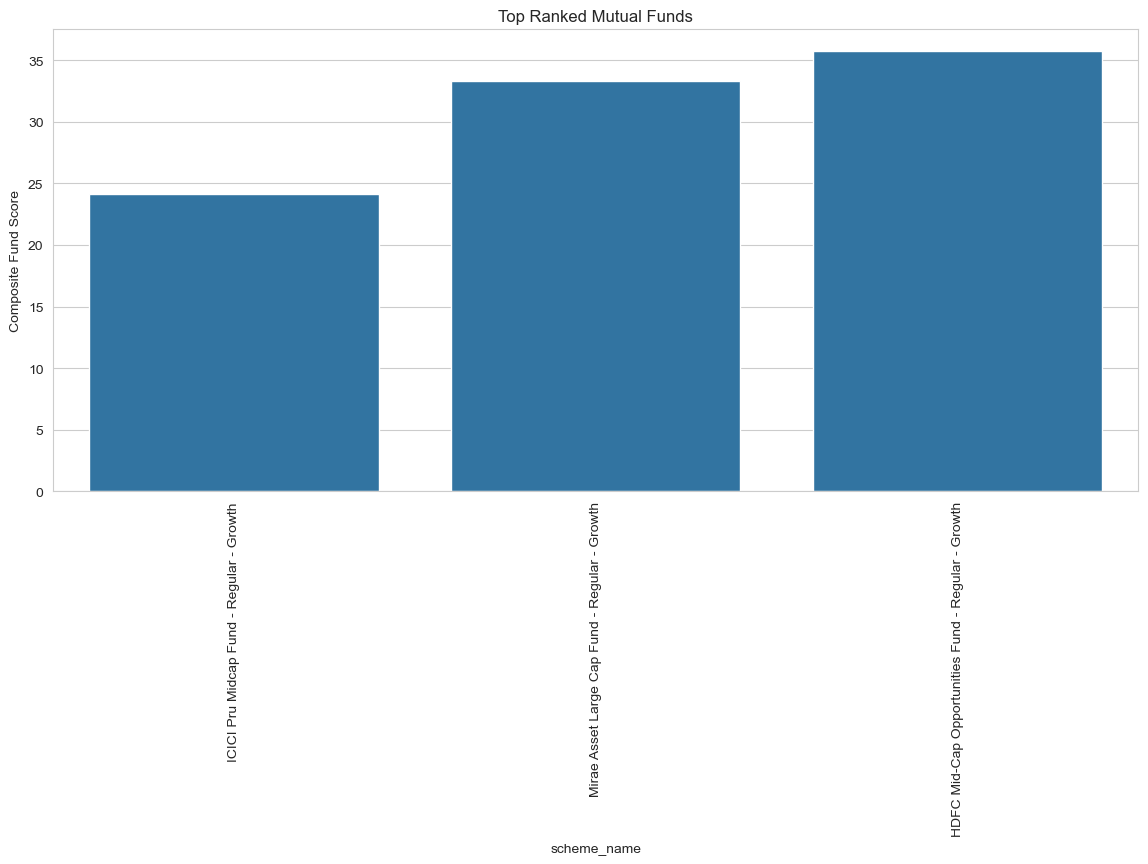

In [83]:

top_funds = final_ranking.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_funds,
    x="scheme_name",
    y="fund_score"
)

plt.xticks(rotation=90)

plt.title("Top Ranked Mutual Funds")

plt.ylabel("Composite Fund Score")

plt.show()



In [84]:

scorecard_df.to_csv(
    "C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv exported successfully")



fund_scorecard.csv exported successfully


In [87]:

alpha_beta_df.to_csv(
    "C:/Users/abdul/OneDrive/Desktop/Bluestock_capstone/data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv exported")



alpha_beta.csv exported
